# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Study Area

The study area is located in the southeastern **Bay of Biscay**, focusing on the **Basque Country coastline** and the surroundings of the **Bilbao harbor and the Nervión Estuary** (approx. 43°20′ N, 3°01′ W).

This North Atlantic region features a relatively **narrow continental shelf** (7–20 km wide) and a **rugged coastline** composed of rocky cliffs and small pocket beaches.

The coastline orientation (N–NW) and the absence of land in that direction provide an **almost unlimited fetch**, exposing the region to energetic waves generated by North Atlantic storms.

![Study Area](../figures/jmse-14-00646-g001.png)

**Figure 1.** Location of the study area in the Bay of Biscay, including the offshore wave buoys used in this study.

## Introduction

In the previous notebook, we approached the coastal wave dataset as a time series forecasting problem.  
In this notebook, we reformulate the task as a **supervised classification problem**.

Instead of predicting the exact wave height value, the goal is to assign each observation to a discrete sea-state category.

This type of approach is useful when wave conditions need to be interpreted in a simpler and more operational way, for example by distinguishing between low, moderate, and high wave energy conditions.

The notebook will follow a standard supervised learning workflow:

1. Data loading and preprocessing  
2. Target construction  
3. Feature selection  
4. Train / validation / test split  
5. Classification model training  
6. Performance evaluation and interpretation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data loading and preprocessing

We begin by loading the coastal wave dataset and applying the same basic preprocessing steps used in the forecasting notebook.

These steps include:

- reading the dataset  
- inspecting the available columns  
- removing invalid or repeated rows  
- converting the date column to datetime format  
- converting relevant variables to numeric format  
- sorting the data chronologically  

This ensures that the dataset is consistent and ready for the classification workflow.

In [5]:
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";", low_memory=False)
df.head()
print(df.columns.tolist())
df.columns = df.columns.str.strip()

df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hs"] = df["Hs"].astype(str).str.strip()

df = df[
    (df["Fecha"] != "Fecha") &
    (df["Fecha"] != "=======") &
    (df["Hs"] != "Hs")
].copy()

df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs_clean"] = pd.to_numeric(df["Hs"], errors="coerce")

df = df.dropna(subset=["Fecha", "Hs_clean"]).copy()
df = df.set_index("Fecha").sort_index()

df.head()

['Fecha', 'Hs', 'Altura signif. de cruce por cero (H1/3)(m)', 'Periodo Medio(s)', 'Periodo Medio Tm02(s)', 'Periodo de Pico(s)', 'Altura Máxima del Oleaje(m)', 'Periodo de la Ola Maxima(s)', 'Canal de obtencion de los datos', 'Direcc. Media de Proced.(0=N,90=E)', 'Direccion Media en el Pico Espectral(0=N,90=E)', 'Dispersión angular en toda la banda resuelta(grados)', 'Dispersión angular en el pico de energía espectral(grados)', 'Canal de obtencion de los datos.1']


,Hs,Altura signif. de cruce por cero (H1/3)(m),Periodo Medio(s),Periodo Medio Tm02(s),Periodo de Pico(s),Altura Máxima del Oleaje(m),Periodo de la Ola Maxima(s),Canal de obtencion de los datos,"Direcc. Media de Proced.(0=N,90=E)","Direccion Media en el Pico Espectral(0=N,90=E)",Dispersión angular en toda la banda resuelta(grados),Dispersión angular en el pico de energía espectral(grados),Canal de obtencion de los datos.1,Hs_clean
Fecha,,,,,,,,,,,,,,
2004-02-26 10:00:00,1.24,1.02,4.01,3.65,4.16,1.54,4.77,1,356,4,-9999.9,32,1,1.24
2004-02-26 10:00:00,1.24,1.02,4.01,3.65,4.16,1.54,4.77,1,356,4,-9999.9,32,1,1.24
2004-02-26 11:00:00,1.54,1.41,4.69,4.05,4.99,2.44,5.12,1,0,358,-9999.9,35,1,1.54
2004-02-26 11:00:00,1.54,1.41,4.69,4.05,4.99,2.44,5.12,1,0,358,-9999.9,35,1,1.54
2004-02-26 12:00:00,1.97,1.77,4.96,4.58,5.4,2.96,6.9,1,2,19,-9999.9,25,1,1.97


## Target construction: sea state classification

To convert the regression problem into a classification task, we define a categorical variable based on the significant wave height (Hs).

We divide the data into three classes using quantiles:

- **Low energy waves**
- **Moderate energy waves**
- **High energy waves**

This approach ensures a balanced distribution of samples across classes.

In [9]:
# Create 3 classes using quantiles
q1 = df["Hs_clean"].quantile(0.33)
q2 = df["Hs_clean"].quantile(0.66)

def classify_hs(h):
    if h <= q1:
        return "Low"
    elif h <= q2:
        return "Moderate"
    else:
        return "High"
#Without seastate there is no classification problem "It is supervised"
df["sea_state"] = df["Hs_clean"].apply(classify_hs)
df["sea_state"].value_counts()

sea_state
High        104400
Low         103944
Moderate    101406
Name: count, dtype: int64

## Feature selection and dataset preparation

In this step, we define the input features (X) and the target variable (y).

We select a subset of relevant physical variables from the dataset, removing non-informative or redundant columns.

The target variable is the categorical sea state defined previously.

Finally, we prepare the dataset for training by separating features and labels.

In [23]:
features = [
    "Periodo Medio(s)",
    "Periodo Medio Tm02(s)",
    "Periodo de Pico(s)",
    "Direcc. Media de Proced.(0=N,90=E)"
]

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_model = df[features + ["sea_state"]].dropna().copy()


### Feature matrix and target variable

We separate the dataset into:

- **X**: input features  
- **y**: target variable (sea state class)

In [24]:

X = df_model[features]
y = df_model["sea_state"]

## Train / Validation / Test split

Since the data is time-dependent, we split the dataset chronologically instead of randomly.

This avoids data leakage and ensures that the model is evaluated on future unseen data.

In [25]:
n = len(df_model)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (216825, 4)
Validation: (46462, 4)
Test: (46463, 4)


## Feature scaling

Before training the model, we scale the input features using a standardization process.

This step ensures that all variables have comparable magnitudes, which is particularly important for models such as logistic regression.

The scaler is fitted only on the training data to avoid data leakage.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Classification model: Logistic Regression

We start with a simple and interpretable baseline model: Logistic Regression.

This model is commonly used for classification tasks and provides a good reference point before exploring more complex models.

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

## Model evaluation

We evaluate the classification performance using standard metrics:

- Accuracy  
- Precision  
- Recall  
- F1-score  

We also use a confusion matrix to better understand classification errors.

In [29]:
from sklearn.metrics import classification_report, accuracy_score

print("Validation results")
print(classification_report(y_val, y_val_pred))

print("\nTest results")
print(classification_report(y_test, y_test_pred))

Validation results
              precision    recall  f1-score   support

        High       0.66      0.71      0.68     16420
         Low       0.62      0.74      0.68     14826
    Moderate       0.43      0.31      0.36     15216

    accuracy                           0.59     46462
   macro avg       0.57      0.59      0.57     46462
weighted avg       0.57      0.59      0.58     46462


Test results
              precision    recall  f1-score   support

        High       0.68      0.64      0.66     15411
         Low       0.61      0.78      0.68     15226
    Moderate       0.44      0.35      0.39     15826

    accuracy                           0.59     46463
   macro avg       0.58      0.59      0.58     46463
weighted avg       0.58      0.59      0.57     46463



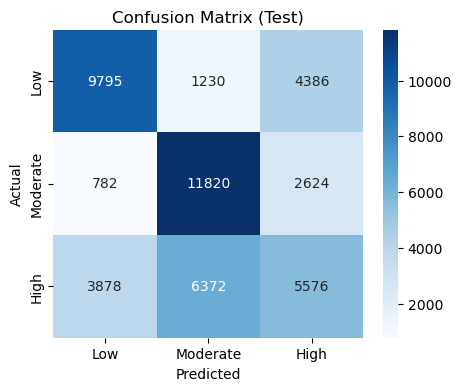

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Moderate", "High"],
            yticklabels=["Low", "Moderate", "High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

## Model performance analysis

The Logistic Regression model provides a reasonable baseline for the classification task, achieving an overall accuracy of approximately **0.59** on both validation and test sets.

This consistency between validation and test performance suggests that the model is **not overfitting** and generalizes reasonably well to unseen data.

### Class-wise performance

A more detailed analysis using the classification report and confusion matrix reveals important differences between classes:

- **Low wave conditions** are predicted with relatively high recall and good overall performance.
- **High wave conditions** are also identified with moderate success, although some confusion with the intermediate class is observed.
- **Moderate wave conditions** show the weakest performance, with significantly lower recall and F1-score.

### Interpretation

This behavior is expected given how the classes were defined:

- The **Low** and **High** classes represent more extreme conditions, which are easier to distinguish.
- The **Moderate** class corresponds to intermediate values, where boundaries between classes are less clear and more ambiguous.

As a result, the model tends to misclassify moderate conditions as either low or high.

### Key insight

This result highlights an important concept in classification problems:

> Not all classes are equally separable.

Intermediate classes often present more difficulty, especially when class boundaries are defined using thresholds.

### Next step

To improve performance, particularly for the moderate class, we will explore a more flexible model capable of capturing non-linear relationships in the data.

## Improving the model: Random Forest

Logistic Regression is a linear model, which means it may struggle to capture complex relationships between variables.

To improve performance, especially for the moderate class, we now test a **Random Forest classifier**.

Random Forest is an ensemble model that combines multiple decision trees and can capture **non-linear patterns** in the data.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, accuracy_score

print("Validation (Random Forest)")
print(classification_report(y_val, y_val_pred_rf))

print("\nTest (Random Forest)")
print(classification_report(y_test, y_test_pred_rf))

print("\nAccuracy:")
print("Validation:", accuracy_score(y_val, y_val_pred_rf))
print("Test:", accuracy_score(y_test, y_test_pred_rf))

Validation (Random Forest)
              precision    recall  f1-score   support

        High       0.63      0.72      0.67     16420
         Low       0.67      0.66      0.67     14826
    Moderate       0.48      0.41      0.44     15216

    accuracy                           0.60     46462
   macro avg       0.59      0.60      0.59     46462
weighted avg       0.59      0.60      0.60     46462


Test (Random Forest)
              precision    recall  f1-score   support

        High       0.62      0.70      0.66     15411
         Low       0.67      0.66      0.66     15226
    Moderate       0.46      0.41      0.43     15826

    accuracy                           0.59     46463
   macro avg       0.58      0.59      0.58     46463
weighted avg       0.58      0.59      0.58     46463


Accuracy:
Validation: 0.6009211829021566
Test: 0.5853044357876159


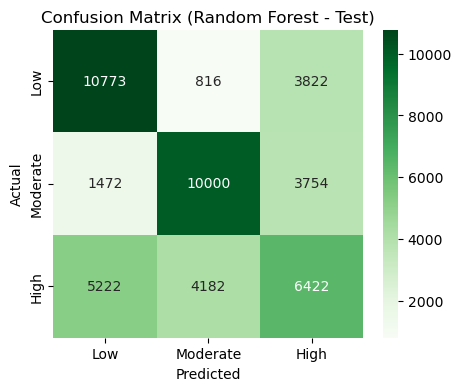

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low", "Moderate", "High"],
            yticklabels=["Low", "Moderate", "High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest - Test)")
plt.show()

## Model comparison

We now compare the performance of Logistic Regression and Random Forest.

Key questions:

- Does Random Forest improve overall accuracy?
- Is the performance on the **moderate class** improved?
- Are extreme classes still well predicted?

This comparison helps us understand the impact of model complexity on classification performance.

In [36]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_test_pred))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_test_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.68      0.64      0.66     15411
         Low       0.61      0.78      0.68     15226
    Moderate       0.44      0.35      0.39     15826

    accuracy                           0.59     46463
   macro avg       0.58      0.59      0.58     46463
weighted avg       0.58      0.59      0.57     46463


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.62      0.70      0.66     15411
         Low       0.67      0.66      0.66     15226
    Moderate       0.46      0.41      0.43     15826

    accuracy                           0.59     46463
   macro avg       0.58      0.59      0.58     46463
weighted avg       0.58      0.59      0.58     46463



## Model comparison: Logistic Regression vs Random Forest

We compare the performance of two models:

- Logistic Regression (linear model)
- Random Forest (non-linear ensemble model)

### Overall performance

Both models achieve a similar overall accuracy (~0.59), indicating that increasing model complexity *does not significantly improve global performance*.

This suggests that the classification task itself is moderately difficult given the available features.

### Class-wise comparison

#### Low class
- Logistic Regression: higher recall (~0.78)
- Random Forest: slightly lower recall (~0.66)

**Logistic Regression performs better** at identifying low-energy wave conditions.

#### High class
- Logistic Regression: recall ~0.64  
- Random Forest: recall improves to ~0.70  

**Random Forest shows better performance** for high-energy conditions.

#### Moderate class (key result)
- Logistic Regression: recall ~0.35  
- Random Forest: recall improves to ~0.41  

**Random Forest improves** the detection of moderate conditions, although performance remains limited.

### Interpretation

The improvement in the moderate class confirms that:

> Non-linear models can better capture complex patterns in the data.



## Feature importance (Random Forest)

Random Forest allows us to estimate the importance of each feature in the classification task.

This helps us understand which physical variables contribute most to distinguishing between sea state conditions.